In [13]:
import os
import re
import sys
import pandas as pd

sys.path.append('..')

from src.keywords import CATEGORY_KEYWORDS

In [14]:
JPspeeches_df = pd.read_csv('data/raw/japan_pm_speeches.csv')
JPspeeches_df.head(10)

,Unnamed: 0,title,date,source,text
0,0,Prime Minister Shigeru Yoshida's Speech at the...,1951-09-07 00:00:00,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1,1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,1977-08-18 00:00:00,The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
2,2,Statement by Prime Minister Takeshita on the O...,1988-05-04 00:00:00,Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
3,3,Policy Speech by Prime Minister Toshiki Kaifu ...,1991-05-03 00:00:00,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
4,4,Address by Prime Minister Toshiki Kaifu at the...,1991-05-27 00:00:00,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."
5,5,Policy Speech by Prime Minister Kiichi Miyazaw...,1992-01-17 00:00:00,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","The Honorable Park Jyun Kyu,\n\nRespected Spea..."
6,6,Statement by Prime Minister Kiichi Miyazawa at...,1992-01-31 00:00:00,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","Prime Minister Major, Secretary-General Boutro..."
7,7,Speech by Prime Minister Kiichi Miyazawa at th...,1992-06-13 00:00:00,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","Mr. Chairman, Mr. Secretary-General, Distingui..."
8,8,Address by Prime Minister Kiichi Miyazawa at t...,1992-07-02 00:00:00,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","President Spears,\n\nDistinguished Guests,\n\n..."
9,9,Opening Remarks by Prime Minister Kiichi Miyaz...,1992-10-29 00:00:00,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","1. Opening Remarks\n\nMr. Chairman,\n\nDisting..."


In [15]:
# Filter by date

JPspeeches_df['date'] = pd.to_datetime(JPspeeches_df['date'])

start_date = '2001-01-01'
end_date = '2021-12-31'

JPspeeches_pd_filtered = JPspeeches_df[JPspeeches_df['date'].between(start_date, end_date)]

JPspeeches_pd_filtered.head(10)

,Unnamed: 0,title,date,source,text
16,16,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02,Ministry of Foreign Affairs of Japan,Having heard the sudden demise of His Majesty ...
17,17,Statement of Prime Minister Junichiro Koizumi,2001-08-13,Ministry of Foreign Affairs of Japan,"The day after tomorrow, August 15, is the fift..."
18,18,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23,The Ministry of Foreign Affairs of Japan,Many lives were lost as a result of the terror...
19,19,Observation by Prime Minister Junichiro Koizum...,2002-04-21,Ministry of Foreign Affairs of Japan,Today I paid a visit to Yasukuni Shrine.\n\nTh...
20,20,"Message from Mr. Junichiro Koizumi, Prime Mini...",2002-04-28,"Ministry of External Affairs, India",On the occasion of the 50th anniversary of the...
21,21,Remarks by Prime Minister Junichiro Koizumi on...,2002-06-20,Ministry of Foreign Affairs of Japan,"His Excellency, Ambassador Farah of Djibuti, D..."
22,22,Inaugural Address by Junichiro Koizumi Prime M...,2003-06-09,Ministry of Foreign Affairs of Japan,"Honourable Ranil Wickremesinghe, Prime Ministe..."
23,23,Address by Junichiro Koizumi Prime Minister of...,2005-01-18,Ministry of Foreign Affairs of Japan,"Mr. Chairperson,\n\nMr. Jan Egeland, UN Under-..."
24,25,"Keynote Speech by Junichiro Koizumi, Prime Min...",2005-04-22,Ministry of Foreign Affairs of Japan,"Mr. Mohamad S. Hidayat, President of the Indon..."
25,24,"Speech by H.E. Mr. Junichiro Koizumi, Prime Mi...",2005-04-22,Ministry of Foreign Affairs of Japan,"Honorable Chairs,\n\nDistinguished participant..."


In [16]:
# Sort by date
JPspeeches_pd_filtered = JPspeeches_pd_filtered.sort_values(by='date')
JPspeeches_pd_filtered.head(10)

,Unnamed: 0,title,date,source,text
16,16,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02,Ministry of Foreign Affairs of Japan,Having heard the sudden demise of His Majesty ...
17,17,Statement of Prime Minister Junichiro Koizumi,2001-08-13,Ministry of Foreign Affairs of Japan,"The day after tomorrow, August 15, is the fift..."
18,18,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23,The Ministry of Foreign Affairs of Japan,Many lives were lost as a result of the terror...
19,19,Observation by Prime Minister Junichiro Koizum...,2002-04-21,Ministry of Foreign Affairs of Japan,Today I paid a visit to Yasukuni Shrine.\n\nTh...
20,20,"Message from Mr. Junichiro Koizumi, Prime Mini...",2002-04-28,"Ministry of External Affairs, India",On the occasion of the 50th anniversary of the...
21,21,Remarks by Prime Minister Junichiro Koizumi on...,2002-06-20,Ministry of Foreign Affairs of Japan,"His Excellency, Ambassador Farah of Djibuti, D..."
22,22,Inaugural Address by Junichiro Koizumi Prime M...,2003-06-09,Ministry of Foreign Affairs of Japan,"Honourable Ranil Wickremesinghe, Prime Ministe..."
23,23,Address by Junichiro Koizumi Prime Minister of...,2005-01-18,Ministry of Foreign Affairs of Japan,"Mr. Chairperson,\n\nMr. Jan Egeland, UN Under-..."
25,24,"Speech by H.E. Mr. Junichiro Koizumi, Prime Mi...",2005-04-22,Ministry of Foreign Affairs of Japan,"Honorable Chairs,\n\nDistinguished participant..."
24,25,"Keynote Speech by Junichiro Koizumi, Prime Min...",2005-04-22,Ministry of Foreign Affairs of Japan,"Mr. Mohamad S. Hidayat, President of the Indon..."


In [17]:
# Drop na values in text
JPspeeches_pd_filtered = JPspeeches_pd_filtered.drop(columns='Unnamed: 0')
JPspeeches_pd_filtered = JPspeeches_pd_filtered.dropna(subset=['text'])
JPspeeches_pd_filtered.head(10)

,title,date,source,text
16,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02,Ministry of Foreign Affairs of Japan,Having heard the sudden demise of His Majesty ...
17,Statement of Prime Minister Junichiro Koizumi,2001-08-13,Ministry of Foreign Affairs of Japan,"The day after tomorrow, August 15, is the fift..."
18,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23,The Ministry of Foreign Affairs of Japan,Many lives were lost as a result of the terror...
19,Observation by Prime Minister Junichiro Koizum...,2002-04-21,Ministry of Foreign Affairs of Japan,Today I paid a visit to Yasukuni Shrine.\n\nTh...
20,"Message from Mr. Junichiro Koizumi, Prime Mini...",2002-04-28,"Ministry of External Affairs, India",On the occasion of the 50th anniversary of the...
21,Remarks by Prime Minister Junichiro Koizumi on...,2002-06-20,Ministry of Foreign Affairs of Japan,"His Excellency, Ambassador Farah of Djibuti, D..."
22,Inaugural Address by Junichiro Koizumi Prime M...,2003-06-09,Ministry of Foreign Affairs of Japan,"Honourable Ranil Wickremesinghe, Prime Ministe..."
23,Address by Junichiro Koizumi Prime Minister of...,2005-01-18,Ministry of Foreign Affairs of Japan,"Mr. Chairperson,\n\nMr. Jan Egeland, UN Under-..."
25,"Speech by H.E. Mr. Junichiro Koizumi, Prime Mi...",2005-04-22,Ministry of Foreign Affairs of Japan,"Honorable Chairs,\n\nDistinguished participant..."
24,"Keynote Speech by Junichiro Koizumi, Prime Min...",2005-04-22,Ministry of Foreign Affairs of Japan,"Mr. Mohamad S. Hidayat, President of the Indon..."


In [18]:
# Count number of total articles
speeches_numrows = len(JPspeeches_pd_filtered)
speeches_numrows

292

In [19]:
# Clean csv info
JPspeeches_pd_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292 entries, 16 to 309
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   title   292 non-null    object        
 1   date    292 non-null    datetime64[ns]
 2   source  290 non-null    object        
 3   text    292 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 11.4+ KB


In [20]:
# Save to csv
# JPspeeches_pd_filtered.to_csv('japan_speeches_cleaned.csv', index=False)

## Graph

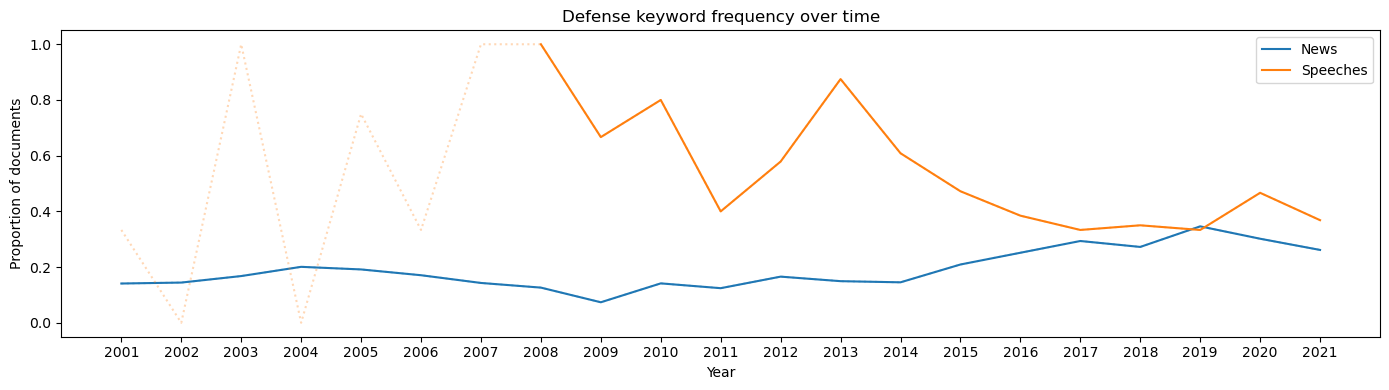

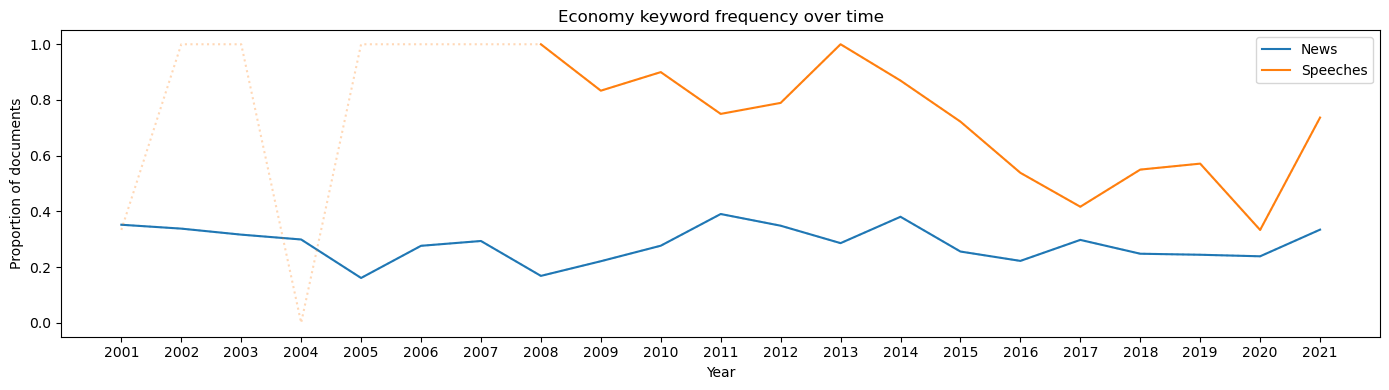

In [21]:
import importlib
from src.graph_articles import keyword_yearly_counts, plot_category

JPspeeches_df = pd.read_csv('data/clean/japan_speeches_cleaned.csv')
JPnews_df = pd.read_csv('data/clean/japan_news_cleaned.csv')

news_results = keyword_yearly_counts(JPnews_df)
speech_results = keyword_yearly_counts(JPspeeches_df)

plot_category('defense', news_results, speech_results, labels=['News', 'Speeches'])
plot_category('economy', news_results, speech_results, labels=['News', 'Speeches'])

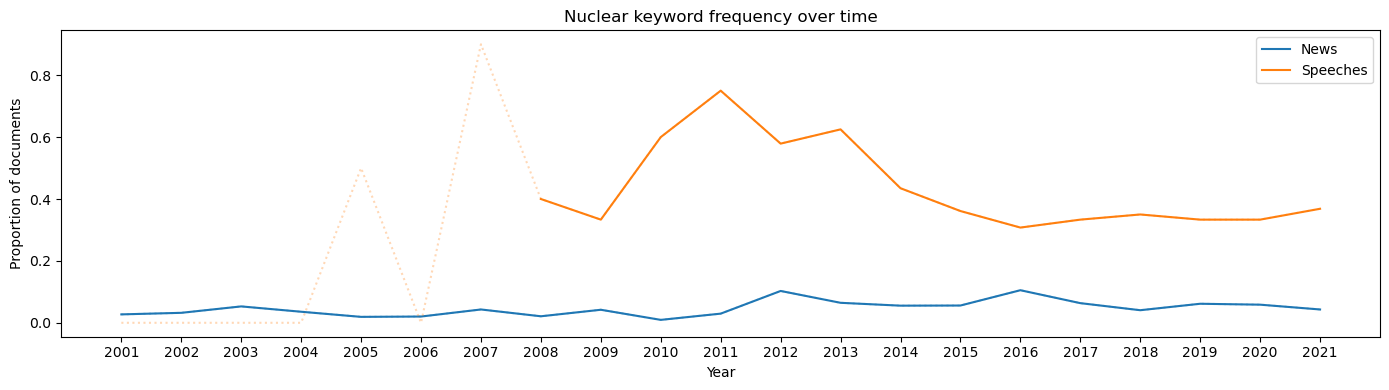

In [22]:
plot_category('nuclear', news_results, speech_results, labels=['News', 'Speeches'])

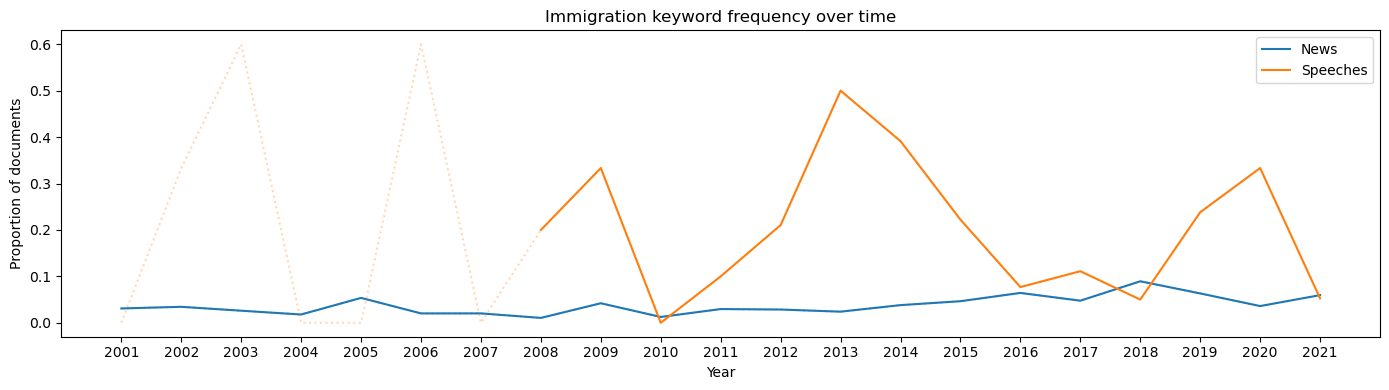

In [23]:
plot_category('immigration', news_results, speech_results, labels=['News', 'Speeches'])